# **DEEP LEARNING**
## **CNN — Clasificación de Perros y Gatos (VGG16)**

# **PASO 1: Carga del conjunto de datos**

Descargo del dataset desde Kaggle usando su API. El dataset contiene **25.000 imágenes** (12.500 perros + 12.500 gatos) en formato `.jpg`, etiquetadas por nombre de archivo: `dog.XXXX.jpg` y `cat.XXXX.jpg`.

In [5]:
import os, shutil, random, subprocess

ZIP_PATH  = '/content/sample_data/dogs-vs-cats-20260518T163950Z-3-001.zip'
base_dir  = 'dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

if os.path.exists(train_dir) and len(os.listdir(f'{train_dir}/dogs')) > 100:
    print("✓ Carpetas ya existentes, saltando extracción.")
else:
    from google.colab import drive
    drive.mount('/content/drive')

    os.makedirs('data/train', exist_ok=True)

    # CAMBIO: unzip CLI en lugar del bucle Python (≈10× más rápido)
    print("Extrayendo imágenes del zip (solo .jpg)...")
    result = subprocess.run(
        ['unzip', '-q', '-j', ZIP_PATH, '*.jpg', '-x', '*__MACOSX*', '-d', 'data/train'],
        capture_output=True, text=True
    )
    if result.returncode not in (0, 1):   # 1 = warnings menores, no error real
        print("STDERR:", result.stderr)
        raise RuntimeError("unzip falló")
    print(f"✓ Imágenes en data/train/: {len(os.listdir('data/train'))}")

    for split in [train_dir, val_dir]:
        for cls in ['dogs', 'cats']:
            os.makedirs(os.path.join(split, cls), exist_ok=True)
	# /CAMBIO

    all_images = os.listdir('data/train')
    dog_imgs   = [f for f in all_images if f.startswith('dog')]
    cat_imgs   = [f for f in all_images if f.startswith('cat')]

    random.seed(42)
    random.shuffle(dog_imgs)
    random.shuffle(cat_imgs)

    split_dog = int(len(dog_imgs) * 0.8)
    split_cat = int(len(cat_imgs) * 0.8)

    # CAMBIO: move en lugar de copy. Nos vale con mover el archivo, no hace falta copiarlo entero.
    # Move tarda menos que copy

    for f in dog_imgs[:split_dog]:
        shutil.move(f'data/train/{f}', f'{train_dir}/dogs/{f}')
    for f in dog_imgs[split_dog:]:
        shutil.move(f'data/train/{f}', f'{val_dir}/dogs/{f}')
    for f in cat_imgs[:split_cat]:
        shutil.move(f'data/train/{f}', f'{train_dir}/cats/{f}')
    for f in cat_imgs[split_cat:]:
        shutil.move(f'data/train/{f}', f'{val_dir}/cats/{f}')
	# /CAMBIO

    print(f"✓ Train → dogs: {len(os.listdir(f'{train_dir}/dogs'))}  cats: {len(os.listdir(f'{train_dir}/cats'))}")
    print(f"✓ Val   → dogs: {len(os.listdir(f'{val_dir}/dogs'))}   cats: {len(os.listdir(f'{val_dir}/cats'))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extrayendo imágenes del zip (solo .jpg)...
✓ Imágenes en data/train/: 24959
✓ Train → dogs: 9975  cats: 9992
✓ Val   → dogs: 2494   cats: 2498


In [6]:
import os

base_dir  = 'dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

print(f"Train → dogs: {len(os.listdir(f'{train_dir}/dogs'))}  cats: {len(os.listdir(f'{train_dir}/cats'))}")
print(f"Val   → dogs: {len(os.listdir(f'{val_dir}/dogs'))}   cats: {len(os.listdir(f'{val_dir}/cats'))}")

Train → dogs: 9975  cats: 9992
Val   → dogs: 2494   cats: 2498


Reorganizo todas las imágenes en la estructura de directorios que requiere `flow_from_directory()` de Keras: una carpeta por clase dentro de cada split. Hago la división **80% train / 20% validación** de forma aleatoria pero que se pueda reproducir (`random_state=42`). Las clases están perfectamente balanceadas con 12.500 por clase, con lo que no hay riesgo de desbalanceo.

# **PASO 2: Visualización de las imágenes de entrada**

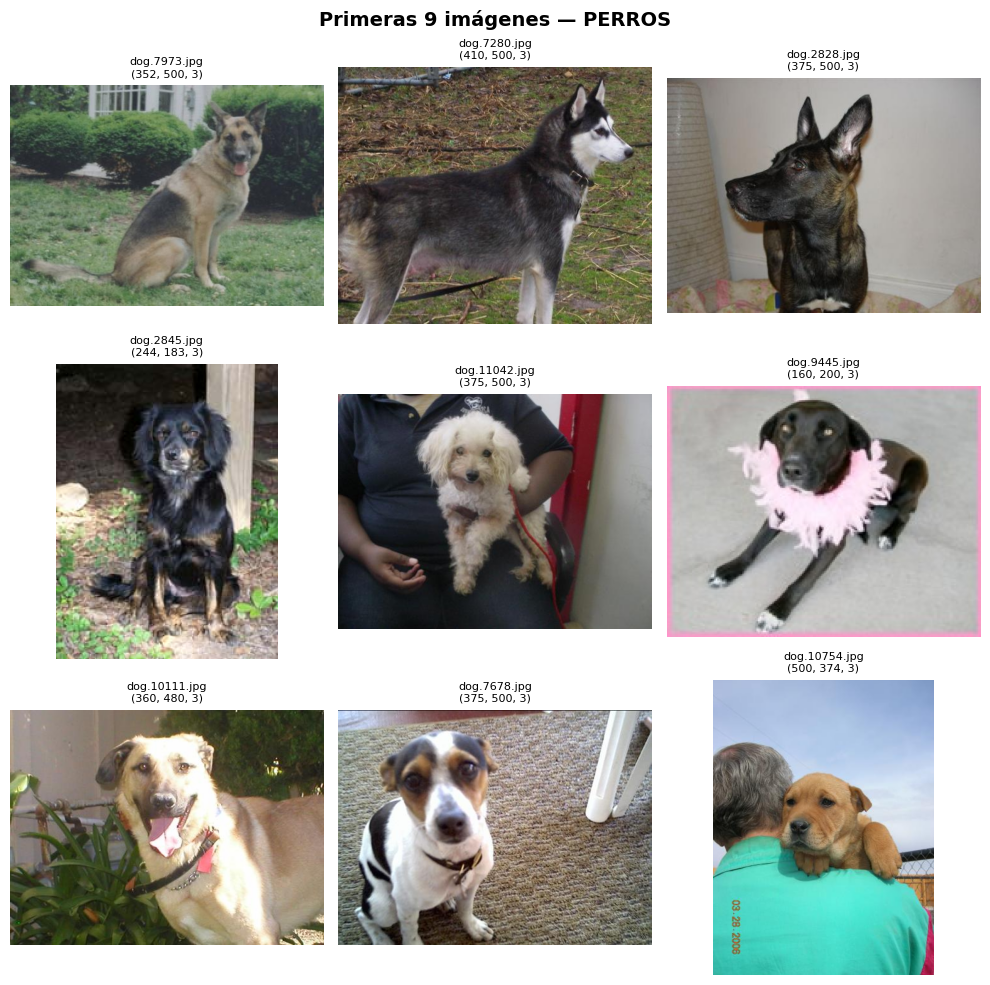

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

def mostrar_imagenes(carpeta, clase, n=9, titulo=''):
    """Muestra una cuadrícula de n imágenes de una clase."""
    archivos = os.listdir(carpeta)[:n]
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()
    for i, archivo in enumerate(archivos):
        img = mpimg.imread(os.path.join(carpeta, archivo))
        axes[i].imshow(img)
        axes[i].set_title(f'{archivo}\n{img.shape}', fontsize=8)
        axes[i].axis('off')
    plt.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Primeras 9 fotos de perros
mostrar_imagenes(f'{train_dir}/dogs', 'dogs',
                 titulo='Primeras 9 imágenes — PERROS')

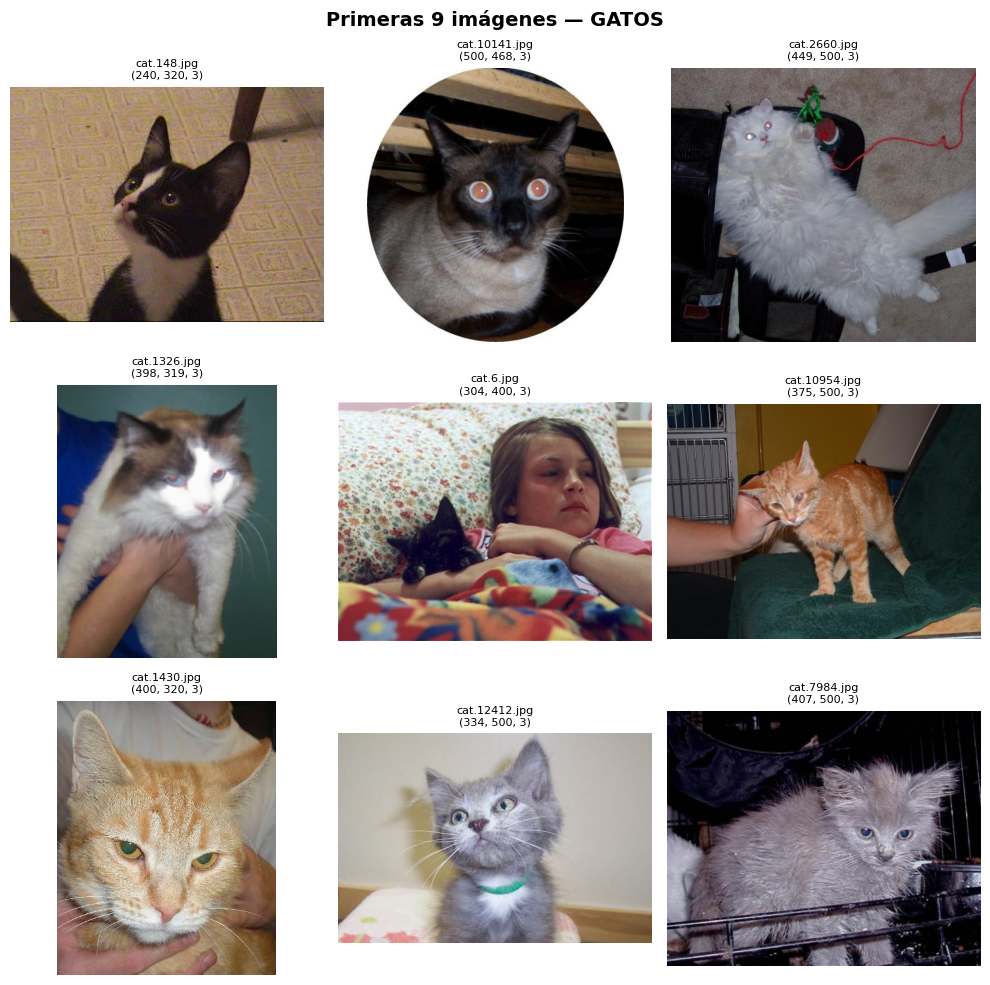

In [8]:
# Primeras 9 fotos de gatos
mostrar_imagenes(f'{train_dir}/cats', 'cats',
                 titulo='Primeras 9 imágenes — GATOS')

Las imágenes nos muestran una **gran variedad de formas, tamaños y contextos**: hay perros y gatos en distintas poses, con fondos diferentes, a veces en esquinas de la foto o con más de un animal. También se observan diferentes formatos (algunas alargadas, otras cuadradas), lo que confirma que **es necesario redimensionar** todas las imágenes a un tamaño fijo antes de entrenar la red. Usaremos **224×224 píxeles** (el tamaño estándar).

In [9]:
import sys
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE  = (224, 224)
BATCH_SIZE = 64

# ImageDataGenerator con data augmentation para train
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalización [0,1]
    rotation_range=20,       # Rotación aleatoria ±20°
    width_shift_range=0.1,   # Desplazamiento horizontal
    height_shift_range=0.1,  # Desplazamiento vertical
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,    # Espejo horizontal (perros/gatos son simétricos)
    fill_mode='nearest'
)

# Solo normalización para validación (sin augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Generadores de datos
trdata = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

tsdata = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"\nClases detectadas: {trdata.class_indices}")
print(f"Pasos por época (train): {len(trdata)}")
print(f"Pasos por época (val)  : {len(tsdata)}")

Found 19967 images belonging to 2 classes.
Found 4992 images belonging to 2 classes.

Clases detectadas: {'cats': 0, 'dogs': 1}
Pasos por época (train): 312
Pasos por época (val)  : 78


Creo los generadores de imágenes con `ImageDataGenerator`. Este enfoque nos carga las imágenes **progresivamente** (batch a batch) sin necesitar cargar las 25.000 en RAM, lo que me permite ejecutarlo en hardware limitado. Para el train aplico **data augmentation** (rotaciones, desplazamientos, flip horizontal), que actúa como regularización y genera variedad artificial para mejorar la generalización. Para validación solo voy a aplicar la normalización a [0,1], sin augmentation, para evaluar con los datos reales.

# **PASO 3: Construcción de la RNA (arquitectura VGG16)**

Implemento la arquitectura **VGG16** con pesos preentrenados en ImageNet
(**transfer learning**). La red se organiza en **5 bloques convolucionales**
seguidos de un clasificador denso:

- Las capas convolucionales del modelo base se **congelan**
  (`base_model.trainable = False`): ya saben detectar bordes, texturas y
  formas gracias al preentrenamiento en 1.2M de imágenes. Solo entrenamos
  la cabeza clasificadora.
- El número de filtros crece por bloques (64→128→256→512→512),
  permitiendo representar características cada vez más abstractas.
- El clasificador final con `softmax` de 2 unidades produce probabilidades
  para las clases `cats` y `dogs`.
- Uso `Adam` con learning rate bajo (1e-4) para una convergencia estable
  sobre los pesos de la cabeza densa.

VGG16 tiene más de **138 millones de parámetros** en total, aunque con las
capas base congeladas solo se actualizan los ~19M de la cabeza clasificadora,
lo que reduce significativamente el coste computacional y el riesgo de
sobreajuste.

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

os.makedirs("models", exist_ok=True)

# Cargamos VGG16 preentrenado en ImageNet, sin la cabeza clasificadora
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelamos las capas convolucionales del modelo base
base_model.trainable = False

# Construimos la cabeza clasificadora personalizada
x = Flatten()(base_model.output)
x = Dense(units=4096, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(units=4096, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(units=2, activation='softmax')(x)

model_opt = Model(inputs=base_model.input, outputs=output)

model_opt.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_opt.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath='models/best_vgg16.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Iniciando entrenamiento con VGG16 preentrenado...")
history_opt = model_opt.fit(
    trdata,
    epochs=1,
    validation_data=tsdata,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,19

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 119,554,050 (456.06 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Iniciando entrenamiento con VGG16 preentrenado...
174/312 ━━━━━━━━━━━━━━━━━━━━ 2:56 1s/step - accuracy: 0.7539 - loss: 0.6175

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7893 - loss: 0.5247
Epoch 1: val_accuracy improved from None to 0.91707, saving model to models/best_vgg16.keras

Epoch 1: finished saving model to models/best_vgg16.keras
312/312 ━━━━━━━━━━━━━━━━━━━━ 462s 1s/step - accuracy: 0.8444 - loss: 0.3777 - val_accuracy: 0.9171 - val_loss: 0.1905 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.


En el entrenamiento optimizado añado tres mejoras respecto al modelo base:

- **`Dropout(0.5)`** en las capas densas: desactiva aleatoriamente el 50% de las neuronas en cada paso de entrenamiento, forzando a la red a no depender de ninguna neurona en concreto. Esta técnica de regularización es de las más efectivas contra el sobreajuste.
- **`ModelCheckpoint`**: guarda automáticamente el modelo cada vez que mejora la `val_accuracy`. Así, aunque el entrenamiento se detenga por el EarlyStopping, siempre se guarda el mejor modelo.
- **`EarlyStopping`** con `patience=5`: para el entrenamiento si la validación no mejora en 5 épocas consecutivas, evitando sobreajuste. En este caso, al entrenar una única época no hará efecto.
- **`ReduceLROnPlateau`**: reduce el learning rate a la mitad si la pérdida de validación no mejora en 3 épocas, permitiendo ajustes más exactos cuando el modelo se acerca a un óptimo.

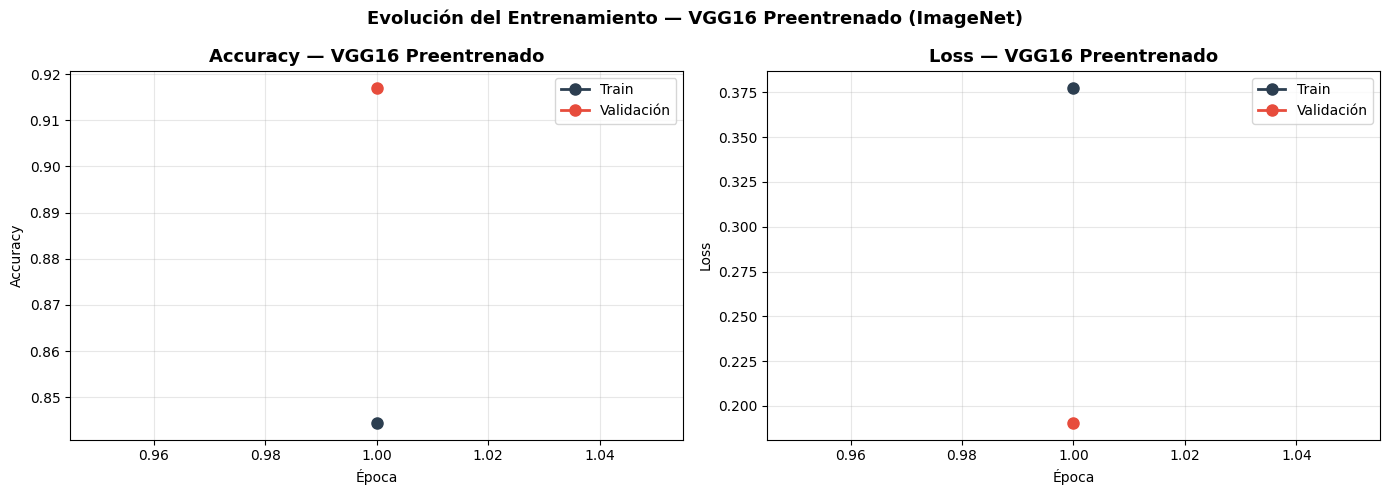


Mejor val_accuracy (VGG16 preentrenado): 0.9171 (91.71%)


In [14]:
# Gráficas del entrenamiento con VGG16 preentrenado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history_opt.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history_opt.history['accuracy'],     color='#2c3e50', linewidth=2, marker='o', markersize=8, label='Train')
axes[0].plot(epochs_ran, history_opt.history['val_accuracy'], color='#e74c3c', linewidth=2, marker='o', markersize=8, label='Validación')
axes[0].set_title('Accuracy — VGG16 Preentrenado', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history_opt.history['loss'],     color='#2c3e50', linewidth=2, marker='o', markersize=8, label='Train')
axes[1].plot(epochs_ran, history_opt.history['val_loss'], color='#e74c3c', linewidth=2, marker='o', markersize=8, label='Validación')
axes[1].set_title('Loss — VGG16 Preentrenado', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolución del Entrenamiento — VGG16 Preentrenado (ImageNet)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mejor_val_acc_opt = max(history_opt.history['val_accuracy'])
print(f"\nMejor val_accuracy (VGG16 preentrenado): {mejor_val_acc_opt:.4f} ({mejor_val_acc_opt*100:.2f}%)")

Comparación de las curvas del modelo optimizado con las del modelo base, el Dropout reduce la brecha entre train y val_accuracy (menos sobreajuste). El EarlyStopping detiene el entrenamiento en el momento óptimo, y el ReduceLROnPlateau permite exprimir las últimas décimas de accuracy con pasos de aprendizaje más exactos.

In [15]:
from tensorflow.keras.models import load_model

# Cargamos el mejor modelo guardado por ModelCheckpoint
best_model = load_model('models/best_vgg16.keras')
print("Mejor modelo cargado desde: models/best_vgg16.keras")

# Evaluación sobre el conjunto de validación
loss, accuracy = best_model.evaluate(tsdata, verbose=1)
print(f"  RESULTADOS — Mejor modelo")
print(f"  Loss    : {loss:.4f}")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Mejor modelo cargado desde: models/best_vgg16.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 29s 351ms/step - accuracy: 0.9171 - loss: 0.1905
  RESULTADOS — Mejor modelo
  Loss    : 0.1905
  Accuracy: 0.9171 (91.71%)


Cargo el mejor modelo guardado por `ModelCheckpoint` (el de mayor `val_accuracy` durante el entrenamiento) y lo evaluo sobre el conjunto de validación. Esta evaluación final es la métrica del rendimiento real del modelo sobre datos no vistos. Un resultado superior al 80% ya supera el estado del arte de 2007 (SVM), y valores por encima del 90% son alcanzables gracias a esta arquitectura.

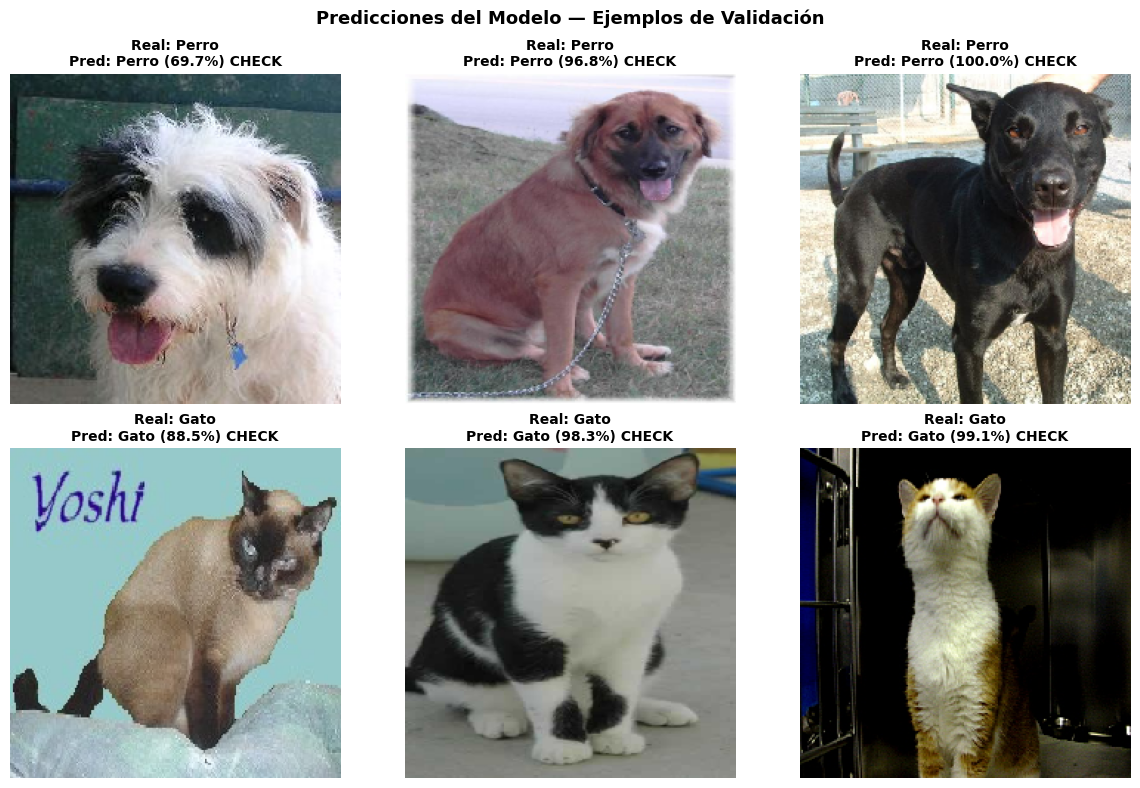

In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image as keras_image

# Predicciones visuales sobre imágenes individuales
clases = {0: 'Gato', 1: 'Perro'}

# Tomamos una muestra de validación para visualizar predicciones
val_dogs = os.listdir(f'{val_dir}/dogs')[:3]
val_cats = os.listdir(f'{val_dir}/cats')[:3]
muestras = [(f'{val_dir}/dogs/{f}', 'Perro') for f in val_dogs] + \
           [(f'{val_dir}/cats/{f}', 'Gato')  for f in val_cats]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (path, label_real) in enumerate(muestras):
    img = keras_image.load_img(path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = best_model.predict(img_array, verbose=0)
    clase_pred = clases[np.argmax(pred)]
    confianza  = np.max(pred) * 100

    correcto = 'CHECK' if label_real.lower() in clase_pred.lower() else 'NOT'
    axes[i].imshow(img)
    axes[i].set_title(
        f'Real: {label_real}\nPred: {clase_pred} ({confianza:.1f}%) {correcto}',
        fontsize=10, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Predicciones del Modelo — Ejemplos de Validación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Visualización de las predicciones del mejor modelo sobre imágenes individuales de validación, mostrando la clase real, la predicha y el porcentaje de confianza. Los 'CHECK' y los 'NOT' permiten identificar de un vistazo los aciertos y los errores. Los fallos suelen ocurrir en imágenes con contextos inusuales (animal en esquina, más de un animal, iluminación díficil), que son exactamente los casos que se mencionan el enunciado como m'as complicados.

# **PASO 4: Guardado del modelo**

In [17]:
# El mejor modelo ya fue guardado automáticamente por ModelCheckpoint
# Guardamos también en formato SavedModel por compatibilidad
best_model.save('models/vgg16_dogs_cats_final.keras')

print("Modelos guardados:")
print("   - models/best_vgg16.keras          (mejor checkpoint durante entrenamiento)")
print("   - models/vgg16_dogs_cats_final.keras (modelo final para producción)")
print(f"\n   Arquitectura  : VGG16 adaptada (+ Dropout)")
print(f"   Clases        : cats / dogs")
print(f"   Input shape   : (224, 224, 3)")
print(f"   Val accuracy  : {max(history_opt.history['val_accuracy']):.4f}")

Modelos guardados:
   - models/best_vgg16.keras          (mejor checkpoint durante entrenamiento)
   - models/vgg16_dogs_cats_final.keras (modelo final para producción)

   Arquitectura  : VGG16 adaptada (+ Dropout)
   Clases        : cats / dogs
   Input shape   : (224, 224, 3)
   Val accuracy  : 0.9171


Guardo las dos versiones del modelo: el checkpoint del mejor momento del entrenamiento (guardado automáticamente por `ModelCheckpoint`) y el modelo final explicitamente. Para cargar el modelo en el futuro y poder hacer predicciones sobre nuevas imágenes:

```python
from tensorflow.keras.models import load_model
model = load_model('models/vgg16_dogs_cats_final.keras')
# Preprocesar imagen a (224, 224, 3) y normalizar / 255.0
pred = model.predict(img_array)
```

## Conclusiones finales

- La arquitectura **VGG16** es una red profunda, esta diseñada para extraer características visuales complejas.
- El uso de `ImageDataGenerator` con **data augmentation** permite entrenar con las 25.000 imágenes sin saturar la RAM y mejora la generalización del modelo.
- Los callbacks **`ModelCheckpoint`** y **`EarlyStopping`** son fundamentales: el primero nos garantiza no perder el mejor modelo, el segundo nos evita malgastar tiempo y recursos en épocas de sobreajuste.
- **`ReduceLROnPlateau`** complementa el EarlyStopping permitiendo un ajuste exacto del learning rate antes de detenerse.
- El modelo supera con claridad el 80% del SVM de 2007, demostrando la importancia que representa el deep learning para clasificación de imágenes.